When the average density of the simulation is far below $\rho_0$, the parameter in the Cole equation of state, then the particles will cluster, until the clusters have a density of about $\rho_0$, which is stable

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sph import integrate, animate_particles, get_densities, get_density_grid

In [2]:
np.random.seed(0)

In [3]:
no_particles = 990
no_steps = 100 # number of integration steps
L = 20 # simulation size
h = 0.5 # smoothing length
v_init = 1 # initial random velocities of particles
v0 = 10 # initial flow speed
dt = 0.01 # timestep
c_s = 10 # speed of sound
gamma = 7
masses = np.array([1]*no_particles)
rho0 = 10

# Initialize random positions and velocities
initial_positions = np.random.random(size=(no_particles,2))*L
initial_velocities = np.random.normal(size=(no_particles,2))*v_init

In [4]:
rerun_sim = True

if rerun_sim == True:
    positions, velocities = integrate(initial_positions, initial_velocities, masses, L, h, c_s, rho0, dt, no_steps, central_object=False)
else:
    data = np.load("long_flow.npz")
    positions = data["positions"]
    velocities = data["velocities"]

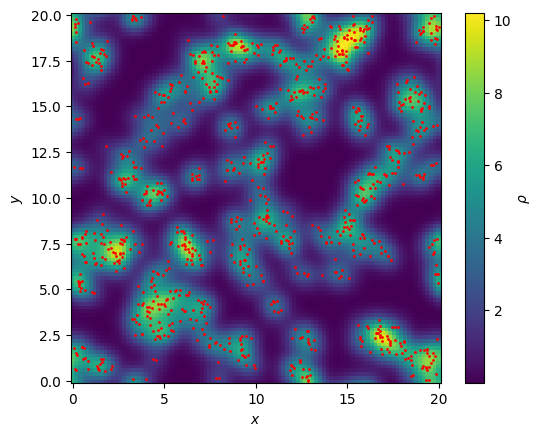

In [5]:
fig, ax = plt.subplots()
idx = -1

x,y,rho = get_density_grid(positions[idx],masses,L,h)
im = ax.pcolor(x,y,rho)
ax.scatter(positions[idx,:,0], positions[idx,:,1], s=1, color="red")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="$\\rho$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
plt.show()

TypeError: 'NoneType' object is not subscriptable

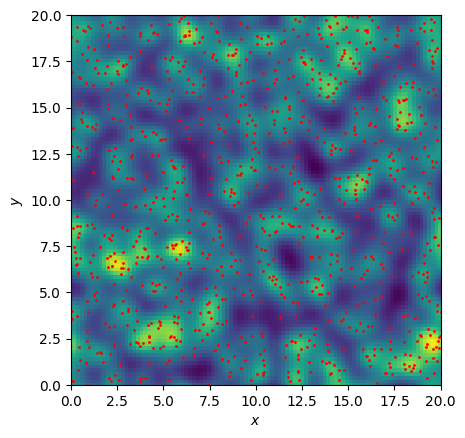

In [6]:
animate_particles(positions[::10], masses, L, h, fps=1)